In [4]:
import pandas as pd

loads = pd.read_csv(r"C:\Users\moham\Documents\DS\Projects\Supply Chain Delay\Data Sets\loads.csv")
trips = pd.read_csv(r"C:\Users\moham\Documents\DS\Projects\Supply Chain Delay\Data Sets\trips.csv")
delivery = pd.read_csv(r"c:\Users\moham\Documents\DS\Projects\Supply Chain Delay\Data Sets\delivery_events.csv")

print("Loads shape:", loads.shape)
print("Trips shape:", trips.shape)
print("Delivery shape:", delivery.shape)

Loads shape: (85410, 12)
Trips shape: (85410, 12)
Delivery shape: (170820, 11)


In [8]:
print("Loads columns:")
print(loads.columns)

print("\nTrips columns:")
print(trips.columns)

print("\nDelivery columns:")
print(delivery.columns)

Loads columns:
Index(['load_id', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'load_status', 'booking_type'],
      dtype='object')

Trips columns:
Index(['trip_id', 'load_id', 'driver_id', 'truck_id', 'trailer_id',
       'dispatch_date', 'actual_distance_miles', 'actual_duration_hours',
       'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'trip_status'],
      dtype='object')

Delivery columns:
Index(['event_id', 'load_id', 'trip_id', 'event_type', 'facility_id',
       'scheduled_datetime', 'actual_datetime', 'detention_minutes',
       'on_time_flag', 'location_city', 'location_state'],
      dtype='object')


In [9]:
df = loads.merge(trips, on="load_id", how="inner")

df.shape

(85410, 23)

In [10]:
df = df.merge(delivery, on=["load_id","trip_id"], how="inner")

df.shape

(170820, 32)

In [11]:
delivery["event_type"].value_counts()

event_type
Pickup      85410
Delivery    85410
Name: count, dtype: int64

In [12]:
df = loads.merge(trips, on="load_id", how="inner")

df.shape

(85410, 23)

In [ ]:
# Step 1:
# The dataset contains both Pickup and Delivery events.
# For delay prediction we only care about the final delivery timing.

delivery_only = delivery[delivery["event_type"] == "Delivery"]


# Step 2: 
# We join using 'load_id' because each shipment (load) has a corresponding trip record.
# how="inner" keeps only rows that exist in BOTH tables.

df = loads.merge(trips, on="load_id", how="inner")


# Step 3:
# Now we combine the previous dataset with delivery events.
# We match using BOTH 'load_id' and 'trip_id' to ensure the correct delivery event is connected to the correct shipment and trip.

df = df.merge(delivery_only, on=["load_id","trip_id"], how="inner")


# Step 4: Check final dataset size

df.shape

(85410, 32)

In [17]:
# Converting scheduled and actual delivery times into datetime format

df["scheduled_datetime"] = pd.to_datetime(df["scheduled_datetime"])
df["actual_datetime"] = pd.to_datetime(df["actual_datetime"])


# Calculating delay in hours
# actual - scheduled gives the time difference

df["delivery_delay_hours"] = (
    df["actual_datetime"] - df["scheduled_datetime"]
).dt.total_seconds() / 3600


# Converting negative delays (early deliveries) to zero
# Because early delivery is not considered a delay

df["delivery_delay_hours"] = df["delivery_delay_hours"].clip(lower=0)


df[["scheduled_datetime","actual_datetime","delivery_delay_hours"]].head()

,scheduled_datetime,actual_datetime,delivery_delay_hours
0,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,0.000000
1,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,3.705453
2,2022-01-03 04:28:02.169634,2022-01-03 03:05:02.833256,0.000000
3,2022-01-02 06:38:56.020030,2022-01-02 08:41:06.714927,2.036304
4,2022-01-02 22:51:35.544202,2022-01-02 22:23:50.185284,0.000000


In [ ]:
# Extracting hour of scheduled delivery
df["scheduled_hour"] = df["scheduled_datetime"].dt.hour

# Extracting day of week
# Monday = 0, Sunday = 6
df["scheduled_day_of_week"] = df["scheduled_datetime"].dt.dayofweek

# Extracting month
df["scheduled_month"] = df["scheduled_datetime"].dt.month

df["is_weekend"] = df["scheduled_day_of_week"].isin([5,6])

df[[
    "scheduled_datetime",
    "scheduled_hour",
    "scheduled_day_of_week",
    "scheduled_month",
    "is_weekend"
]].head()

,scheduled_datetime,scheduled_hour,scheduled_day_of_week,scheduled_month,is_weekend
0,2022-01-02 23:10:55.918185,23,6,1,True
1,2022-01-02 02:13:26.608430,2,6,1,True
2,2022-01-03 04:28:02.169634,4,0,1,False
3,2022-01-02 06:38:56.020030,6,6,1,True
4,2022-01-02 22:51:35.544202,22,6,1,True


In [22]:
df[[
    "actual_distance_miles",
    "fuel_gallons_used",
    "revenue",
    "average_mpg"
]].describe()

,actual_distance_miles,fuel_gallons_used,revenue,average_mpg
count,85410.000000,85410.000000,85410.000000,85410.000000
mean,1430.268130,221.827422,3073.712683,6.501463
std,801.931973,126.558874,1883.127436,0.578091
min,90.000000,12.000000,125.930000,5.500000
25%,717.000000,111.800000,1443.215000,6.000000
50%,1297.500000,204.500000,2827.985000,6.500000
75%,2147.000000,326.400000,4323.157500,7.000000
max,3391.000000,611.900000,8125.220000,7.500000


In [23]:
#Adding Feature
#F1 - Revenue per mile
df["revenue_per_mile"] = df["revenue"] / df["actual_distance_miles"]


# F2 - Calculate MPG from fuel usage
df["calculated_mpg"] = df["actual_distance_miles"] / df["fuel_gallons_used"]


# F3 - Idle ratio
df["idle_ratio"] = df["idle_time_hours"] / df["actual_duration_hours"]


df[[
    "revenue",
    "actual_distance_miles",
    "revenue_per_mile",
    "calculated_mpg",
    "idle_ratio"
]].head()

,revenue,actual_distance_miles,revenue_per_mile,calculated_mpg,idle_ratio
0,3045.23,1314,2.317527,7.149075,0.133588
1,1224.48,515,2.377631,5.502137,0.965116
2,7171.12,2509,2.858159,7.398997,0.266667
3,1308.20,717,1.824547,6.500453,0.864865
4,3317.18,2243,1.478903,6.819702,0.331429


In [24]:
#EXPLORATORY DATA ANALYSIS

# Creating a binary delay variable
df["is_delayed"] = (df["delivery_delay_hours"] > 1).astype(int)

# Checking distribution
df["is_delayed"].value_counts()

df["is_delayed"] = (df["delivery_delay_hours"] > 1).astype(int)
df["is_delayed"].value_counts()

is_delayed
1    47391
0    38019
Name: count, dtype: int64

In [25]:
# Creating distance categories (buckets) from the continuous distance variable

df["distance_bucket"] = pd.cut(
    
    # Column containing trip distances
    df["actual_distance_miles"],
    
    # Define bucket ranges
    # Example: 0-500 miles, 500-1000 miles, etc.
    bins=[0, 500, 1000, 1500, 2000, 4000],
    
    labels=[
        "0-500",
        "500-1000",
        "1000-1500",
        "1500-2000",
        "2000+"
    ]
)

df["distance_bucket"].value_counts()

distance_bucket
2000+        25656
500-1000     25352
1000-1500    15582
1500-2000    11619
0-500         7201
Name: count, dtype: int64

In [26]:
# Grouping the dataset by distance bucket & Then calculating the average of "is_delayed"
delay_by_distance = df.groupby("distance_bucket")["is_delayed"].mean()

# Explanation:
# is_delayed values are 0 or 1
# Taking the mean gives the delay percentage
# Example: 0.62 = 62% of trips delayed

delay_by_distance

C:\Users\moham\AppData\Local\Temp\ipykernel_17884\2225658419.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_by_distance = df.groupby("distance_bucket")["is_delayed"].mean()


distance_bucket
0-500        0.558256
500-1000     0.552304
1000-1500    0.554037
1500-2000    0.556158
2000+        0.556361
Name: is_delayed, dtype: float64

In [27]:
# Creating idle ratio buckets to categorize trips by how much idle time they had
df["idle_bucket"] = pd.cut(
    
    df["idle_ratio"],
    
    bins=[0, 0.1, 0.25, 0.5, 1.0],
    
    labels=[
        "0-10%",
        "10-25%",
        "25-50%",
        "50%+"
    ]
)

df["idle_bucket"].value_counts()

idle_bucket
10-25%    28975
25-50%    25875
50%+      15662
0-10%      7448
Name: count, dtype: int64

In [28]:
# Grouping trips by idle bucket and calculating delay rate
idle_delay_analysis = df.groupby("idle_bucket")["is_delayed"].mean()

idle_delay_analysis

C:\Users\moham\AppData\Local\Temp\ipykernel_17884\329352225.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  idle_delay_analysis = df.groupby("idle_bucket")["is_delayed"].mean()


idle_bucket
0-10%     0.551557
10-25%    0.554685
25-50%    0.554976
50%+      0.555102
Name: is_delayed, dtype: float64

In [29]:
# Creating detention time categories to analyze how waiting time at facilities affects delays
df["detention_bucket"] = pd.cut(
    
    df["detention_minutes"],
    
    bins=[-1, 0, 30, 60, 120, 10000],
    
    labels=[
        "0",
        "0-30",
        "30-60",
        "60-120",
        "120+"
    ]
)

df["detention_bucket"].value_counts()

detention_bucket
120+      37856
60-120    18941
0          9695
0-30       9551
30-60      9367
Name: count, dtype: int64

In [30]:
# Calculating delay probability for each detention bucket
detention_delay_analysis = df.groupby("detention_bucket")["is_delayed"].mean()

detention_delay_analysis

C:\Users\moham\AppData\Local\Temp\ipykernel_17884\1977184984.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  detention_delay_analysis = df.groupby("detention_bucket")["is_delayed"].mean()


detention_bucket
0         0.552140
0-30      0.552193
30-60     0.551938
60-120    0.550605
120+      0.559092
Name: is_delayed, dtype: float64

In [31]:
df["detention_bucket"].value_counts()

detention_bucket
120+      37856
60-120    18941
0          9695
0-30       9551
30-60      9367
Name: count, dtype: int64

In [32]:
detention_delay_analysis

detention_bucket
0         0.552140
0-30      0.552193
30-60     0.551938
60-120    0.550605
120+      0.559092
Name: is_delayed, dtype: float64

In [33]:
# Selecting numeric columns from the dataset
numeric_df = df.select_dtypes(include=["number"])

# Calculating correlation matrix between all numeric variables
correlation_matrix = numeric_df.corr()

correlation_matrix["delivery_delay_hours"].sort_values(ascending=False)

delivery_delay_hours     1.000000
is_delayed               0.839191
pieces                   0.005168
detention_minutes        0.004220
idle_time_hours          0.003957
idle_ratio               0.003334
scheduled_day_of_week    0.001536
scheduled_month          0.000599
fuel_surcharge           0.000453
accessorial_charges     -0.000024
scheduled_hour          -0.000194
average_mpg             -0.000435
calculated_mpg          -0.000436
actual_duration_hours   -0.000678
actual_distance_miles   -0.000937
fuel_gallons_used       -0.001129
weight_lbs              -0.001957
revenue                 -0.003657
revenue_per_mile        -0.008740
Name: delivery_delay_hours, dtype: float64

In [35]:
features = [
    "actual_distance_miles",
    "actual_duration_hours",
    "fuel_gallons_used",
    "average_mpg",
    "idle_time_hours",
    "detention_minutes",
    "weight_lbs",
    "pieces",
    "revenue",
    "scheduled_hour",
    "scheduled_day_of_week",
    "scheduled_month",
    "is_weekend"
]

# feature matrix (X) and target variable (y)
X = df[features]
y = df["is_delayed"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (85410, 13)
Target shape: (85410,)


In [37]:
#Train/Split data sets

# Importing train_test_split function from sklearn
from sklearn.model_selection import train_test_split


# Spliting dataset into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility (same split every time)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Print shapes to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (68328, 13)
X_test shape: (17082, 13)
y_train shape: (68328,)
y_test shape: (17082,)


In [41]:
#Training the Model
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

# Create model with higher iteration limit
model = LogisticRegression(max_iter=5000)

# Train model
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5520430862896616


In [44]:
#Training with Random Forrest Model

# Importing Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Creating the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,     # number of trees in the forest
    random_state=42       # ensures reproducibility
)

# Training the model using training data
rf_model.fit(X_train, y_train)

# Predict delays for test dataset
rf_pred = rf_model.predict(X_test)

# Import accuracy metric
from sklearn.metrics import accuracy_score

# Calculate accuracy of the model
rf_accuracy = accuracy_score(y_test, rf_pred)

# Printing the accuracy result
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.5288607891347618


In [45]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

# Sort features by importance
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

weight_lbs               0.106450
revenue                  0.102496
fuel_gallons_used        0.094084
average_mpg              0.092738
actual_distance_miles    0.092098
detention_minutes        0.089566
actual_duration_hours    0.089228
idle_time_hours          0.088908
pieces                   0.072232
scheduled_hour           0.066537
scheduled_month          0.054905
scheduled_day_of_week    0.042042
is_weekend               0.008716
dtype: float64

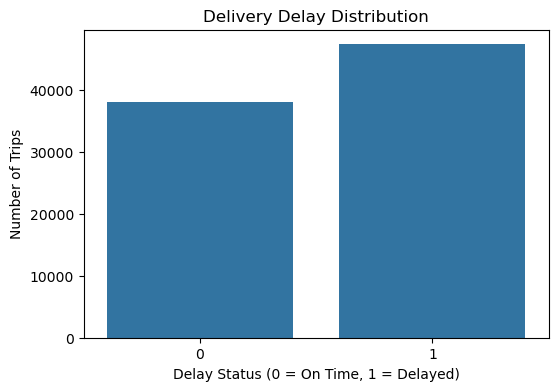

In [46]:
#1 — Visualize Delay Distribution
import matplotlib.pyplot as plt
import seaborn as sns


# Plot delay distribution
plt.figure(figsize=(6,4))

sns.countplot(x="is_delayed", data=df)

plt.title("Delivery Delay Distribution")
plt.xlabel("Delay Status (0 = On Time, 1 = Delayed)")
plt.ylabel("Number of Trips")

plt.show()

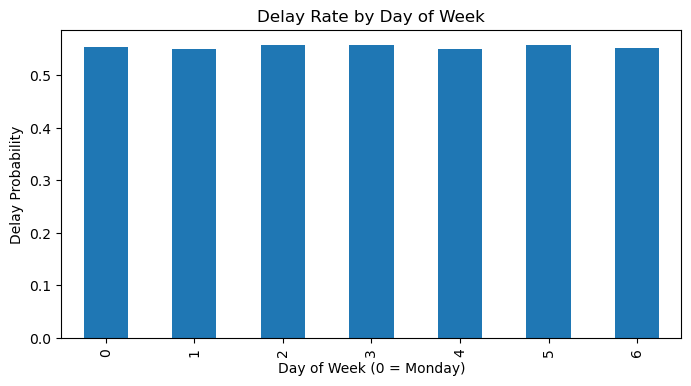

In [47]:
#2 — Delay Rate by Day of Week
# Calculate delay rate by weekday
delay_by_day = df.groupby("scheduled_day_of_week")["is_delayed"].mean()

plt.figure(figsize=(8,4))

delay_by_day.plot(kind="bar")

plt.title("Delay Rate by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Delay Probability")

plt.show()

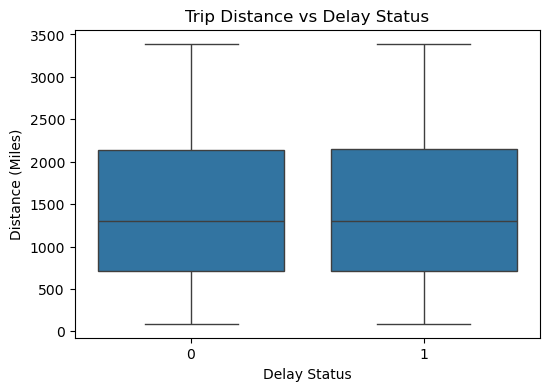

In [48]:
#3 — Distance vs Delay Visualization
plt.figure(figsize=(6,4))

sns.boxplot(
    x="is_delayed",
    y="actual_distance_miles",
    data=df
)

plt.title("Trip Distance vs Delay Status")
plt.xlabel("Delay Status")
plt.ylabel("Distance (Miles)")

plt.show()

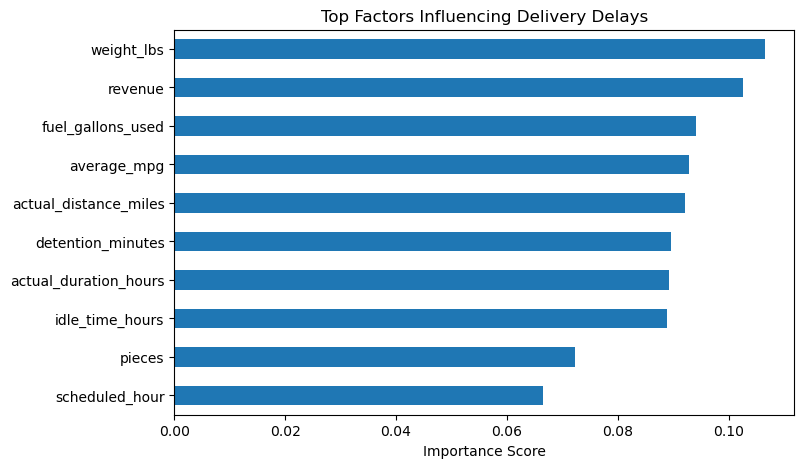

In [49]:
#4 — Feature Importance Visualization
# Plot feature importance

plt.figure(figsize=(8,5))

feature_importance.head(10).plot(kind="barh")

plt.title("Top Factors Influencing Delivery Delays")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

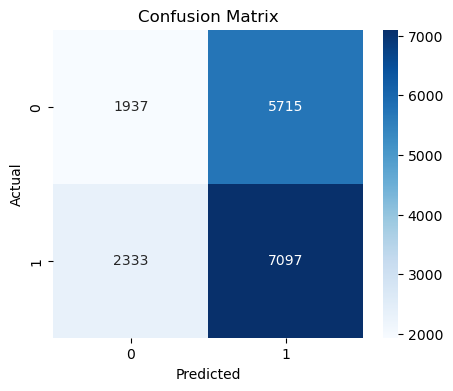

In [50]:
#5 — Model Performance Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

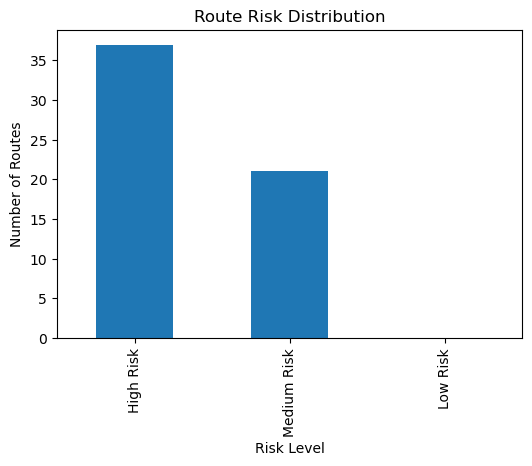

In [51]:
#Route Risk Scoring

#1 — Calculate Delay Rate by Route
route_risk = df.groupby("route_id")["is_delayed"].agg(
    total_trips="count",
    delay_rate="mean"
).reset_index()

#2 — Creating Risk Categories
# Classify routes into risk levels
route_risk["risk_level"] = pd.cut(
    route_risk["delay_rate"],
    bins=[0, 0.4, 0.55, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

#3 — Visualize Risk Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

route_risk["risk_level"].value_counts().plot(kind="bar")

plt.title("Route Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Routes")

plt.show()

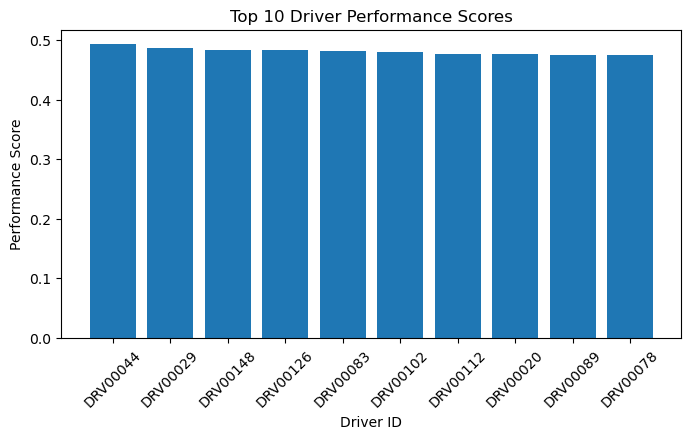

In [52]:
#Driver Performance Ranking

#1 — Calculate Driver Metrics
driver_performance = df.groupby("driver_id").agg(
    
    total_trips=("trip_id", "count"),
    delay_rate=("is_delayed", "mean"),
    avg_idle=("idle_time_hours", "mean")
    
).reset_index()

#2 — Filter Drivers with Enough Trips
driver_performance = driver_performance[
    driver_performance["total_trips"] >= 20
]

#3 — Rank Drivers
driver_performance["performance_score"] = (
    1 - driver_performance["delay_rate"]
)

driver_performance = driver_performance.sort_values(
    "performance_score",
    ascending=False
)

#4 — Visualize Top Drivers
top_drivers = driver_performance.head(10)

plt.figure(figsize=(8,4))

plt.bar(top_drivers["driver_id"].astype(str), top_drivers["performance_score"])

plt.title("Top 10 Driver Performance Scores")
plt.xlabel("Driver ID")
plt.ylabel("Performance Score")

plt.xticks(rotation=45)

plt.show()

In [54]:
#Delay Prediction Dashboard

#1 — Key Operational KPIs
total_trips = len(df)

delay_rate = df["is_delayed"].mean()

avg_distance = df["actual_distance_miles"].mean()

avg_detention = df["detention_minutes"].mean()

print("Total Trips:", total_trips)
print("Delay Rate:", round(delay_rate, 3))
print("Average Distance:", round(avg_distance, 1))
print("Average Detention:", round(avg_detention, 1))

Total Trips: 85410
Delay Rate: 0.555
Average Distance: 1430.3
Average Detention: 106.6


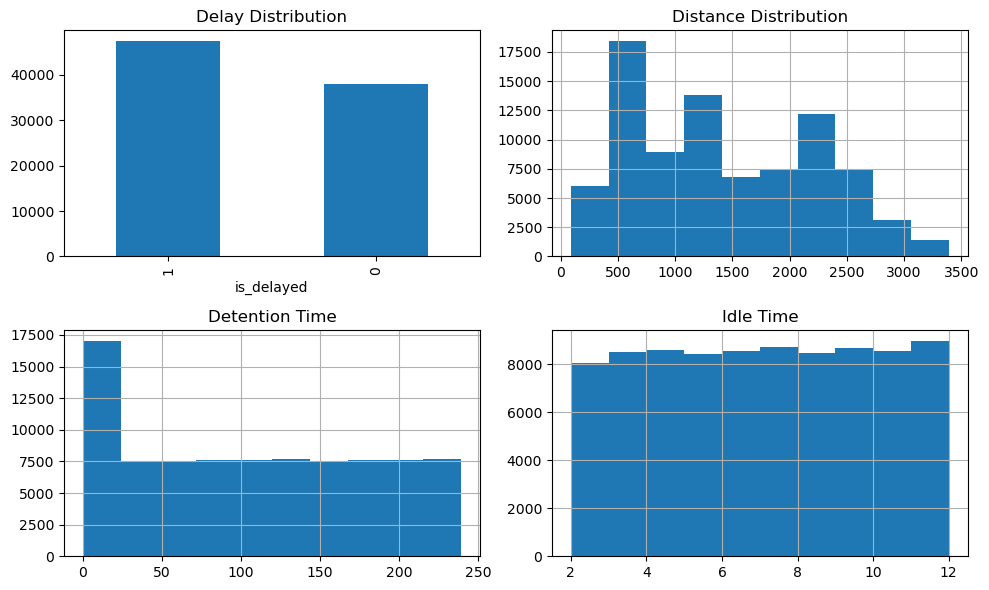

In [55]:
#2 — Dashboard Style Visualization

plt.figure(figsize=(10,6))

# Delay distribution
plt.subplot(2,2,1)
df["is_delayed"].value_counts().plot(kind="bar")
plt.title("Delay Distribution")

# Distance distribution
plt.subplot(2,2,2)
df["actual_distance_miles"].hist()
plt.title("Distance Distribution")

# Detention distribution
plt.subplot(2,2,3)
df["detention_minutes"].hist()
plt.title("Detention Time")

# Idle time distribution
plt.subplot(2,2,4)
df["idle_time_hours"].hist()
plt.title("Idle Time")

plt.tight_layout()
plt.show()